# **GSEA/ORA**

### Author: Holly Vose
### Last Updated: 6/4/26

Test of the GSEA/ORA functionalities of GSEApy and built-in Enrichr queries.

In [1]:
# STEP 1: Imports
import re
import os
import pprint
import time
import warnings
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gprofiler
import gseapy as gp
from gseapy import dotplot
import harmonypy as hm
import decoupler as dc

warnings.filterwarnings('ignore')
sns.set_style("ticks")
sns.set_theme(style="white", context="paper")

/projects/hvose@xsede.org/software/anaconda/envs/jupyter_scrna/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# STEP 2: Load Data
#live = sc.read_h5ad("20260423_live_recluster.h5ad")
# diet = sc.read_h5ad("20260423_diet_hm_recluster.h5ad")
live_redo = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260605_annotated_live.h5ad")
dhe_redo = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260608_dhe_epcam_annotated.h5ad")

In [4]:
print(live_redo.shape)
print(dhe_redo.shape)

(58854, 21247)
(58919, 18506)


In [3]:
#STEP 4: LOAD COLOR PALETTES
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E5283",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  "#009499",
                  "#E3BD33",
                  "#C67FAE",
                  "#A6BE47",
                  "#D7E8BC",
                  "#6D5698",
                  "#98DDDF",
                  "#A00239",
                  "#B623CC",
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  "#0D199A",
                  "#F53C9F",
                  "#BAA5FF",
                 "#FCD581"]
i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

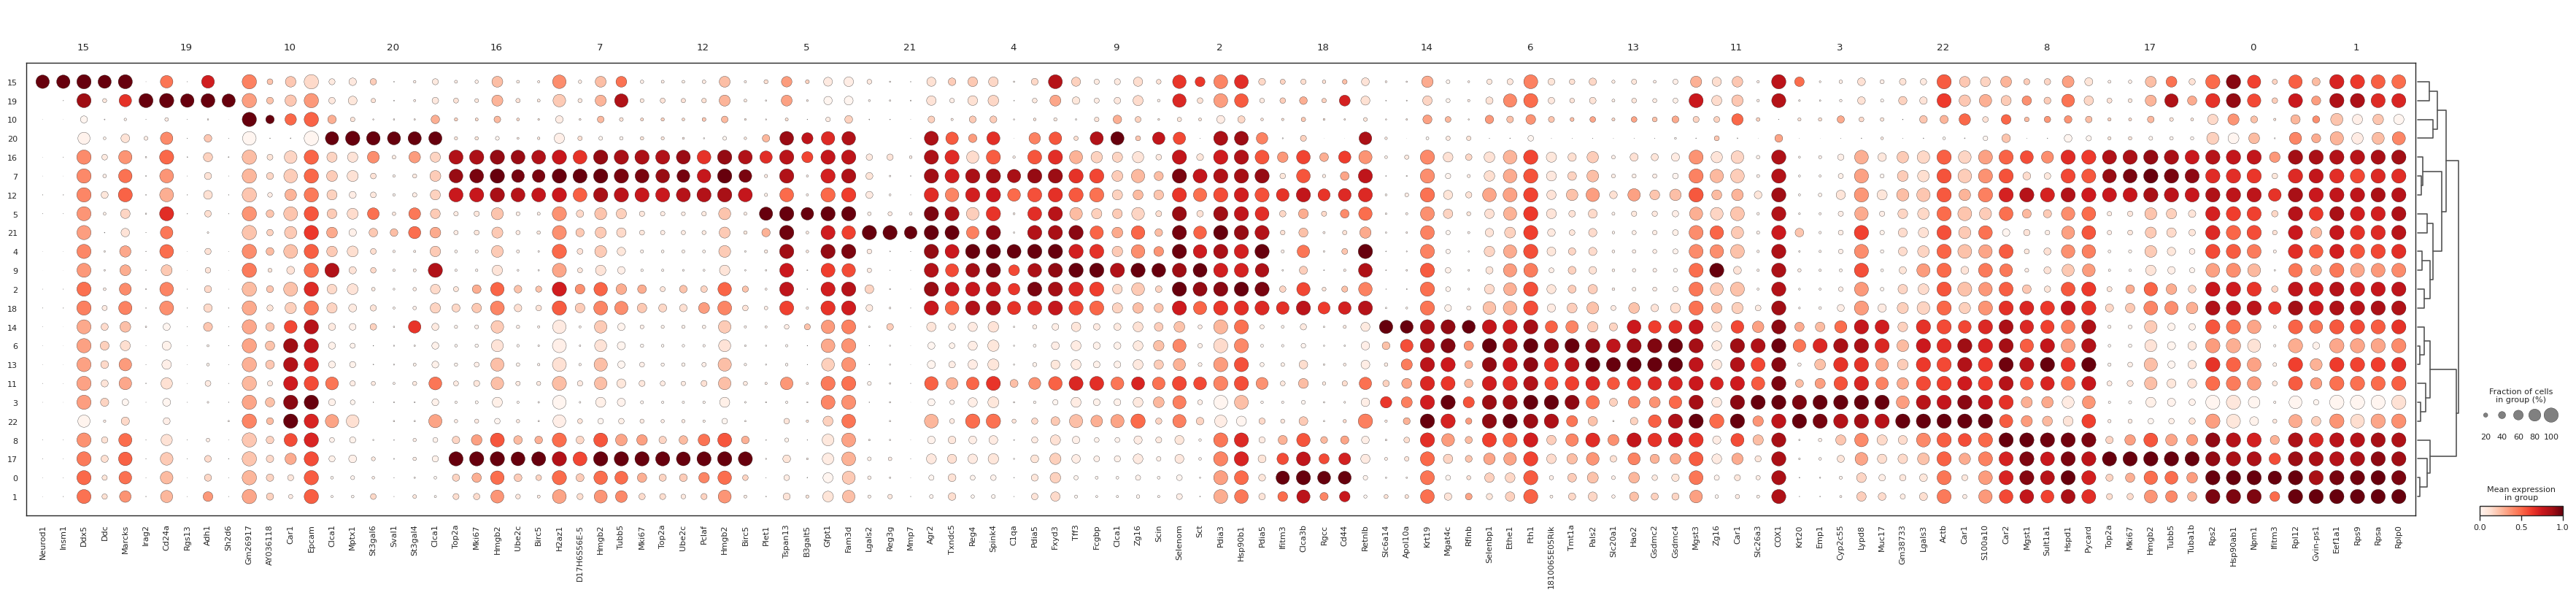

In [21]:
#generate most differentially expressed genes per cluster
sc.tl.rank_genes_groups(live_redo, groupby="leiden_res_1.00", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    live_redo, groupby="leiden_res_1.00", standard_scale="var", n_genes=5
)

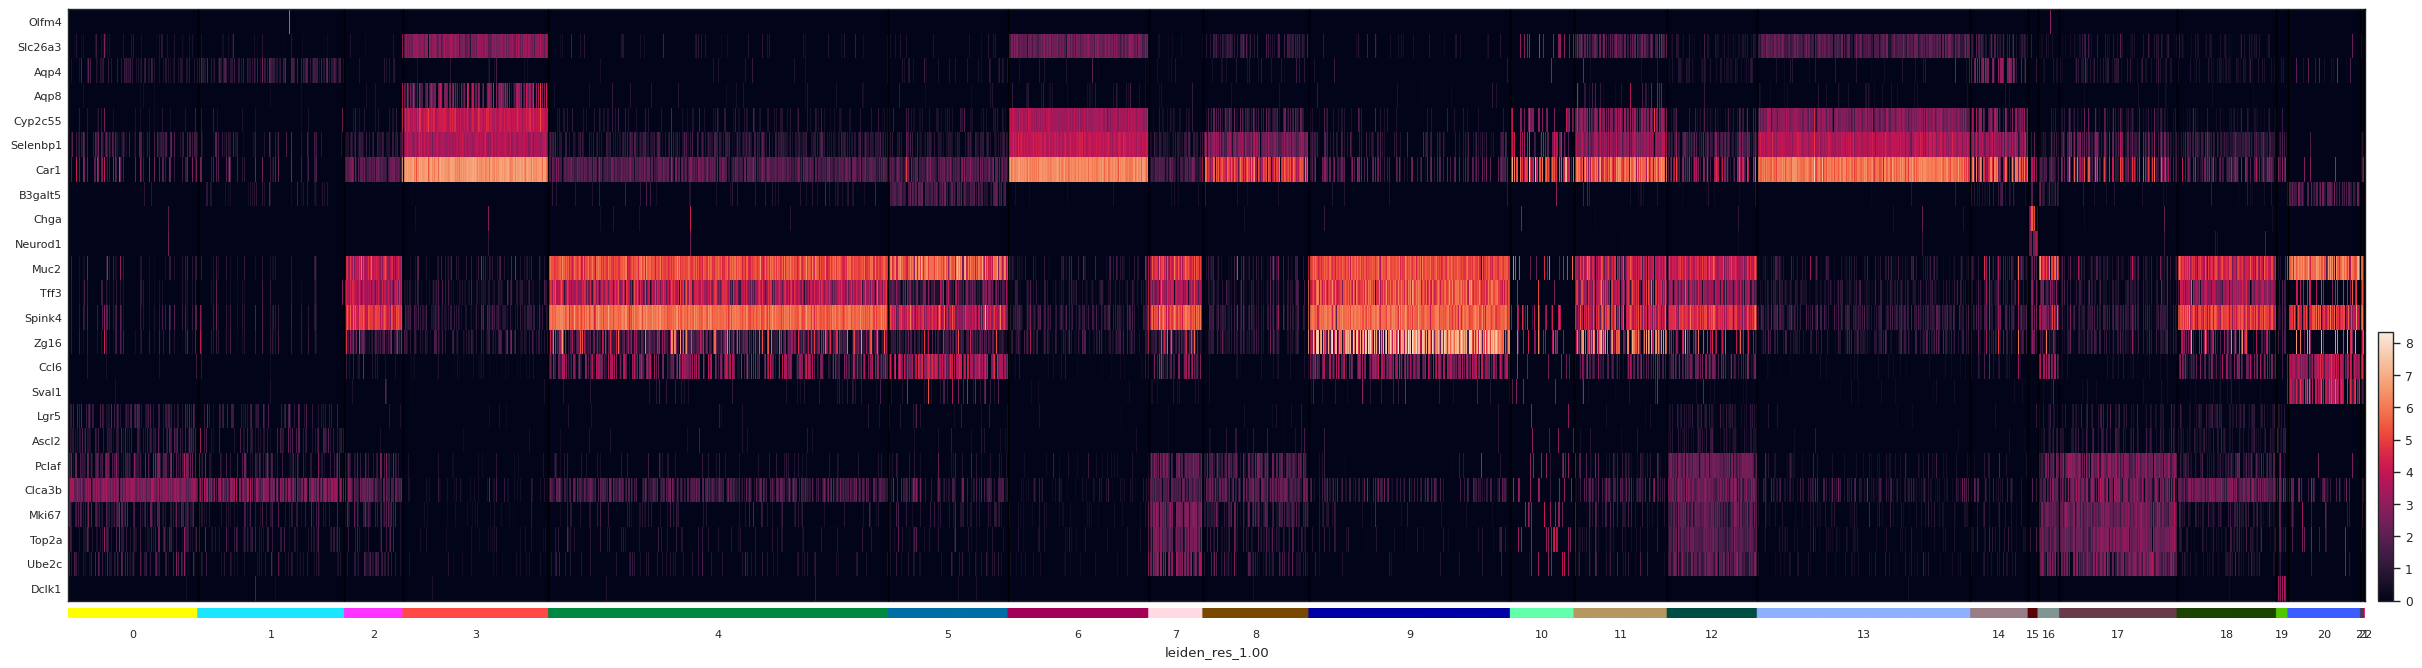

In [19]:

markers = ["Olfm4","Slc26a3", "Aqp4", "Aqp8", "Cyp2c55", "Selenbp1", "Car1", "B3galt5", "Chga", "Neurod1", "Muc2", "Tff3", "Spink4", "Zg16", "Ccl6", "Sval1", "Lgr5", "Ascl2", "Pclaf", "Clca3b","Mki67", "Top2a", "Ube2c", "Dclk1"]

sc.pl.heatmap(live_redo,markers,groupby="leiden_res_1.00",figsize=(30,8),swap_axes=True)

In [ ]:
sc.pl.umap(live_epcam,color="leiden_res_0.75",legend_loc="on data")
sc.pl.umap(live_epcam,color="Tff3",cmap=ifitm_cmap)
sc.pl.umap(live_epcam,color="Sval1",cmap=ifitm_cmap,mask_obs=(live_epcam.obs["i_type"]=="Mock"))
sc.pl.umap(live_epcam,color="Sval1",cmap=ifitm_cmap,mask_obs=(live_epcam.obs["i_type"]=="5DPI"))
sc.pl.umap(live_epcam,color="Clca1",cmap=ifitm_cmap)
sc.pl.umap(live_epcam,color="Spdef",cmap=ifitm_cmap)
sc.pl.umap(live_epcam,color="Atoh1")
sc.pl.umap(live_epcam,color="Reg4")

# **CLUSTER CELL DEFINITIONS**

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

diet_annotation = {
    "0": "Absorptive Progenitors",
    "1": "Absorptive Colonocytes",
    "2": "Aging Goblet Cells", 
    "3": "Stem Cells", 
    "4": "Goblet Cells", 
    "5": "Deep-crypt Goblet Cell",
    "6": "Goblet Cells",
    "7": "Goblet Cells",
    "8": "Absorptive Progenitors",
    "9": "Deep-crypt Goblet Cell",
    "10": "Absorptive Progenitors",
    "11": "Absorptive Colonocytes",
    "12": "Aging Goblet Cells",
    "13": "Absorptive Colonocytes",
    "14": "Goblet Cells",
    "15": "Secretory Progenitors",
    "16": "Transit Amplifying Cells",
    "17": "Absorptive Colonocytes",
    "18": "Absorptive Colonocytes",
    "19": "Absorptive Colonocytes",
    "20": "Absorptive Colonocytes",
    "21": "Absorptive Colonocytes",
    "22": "Enteroendocrine Cells",
    "23": "Absorptive Colonocytes",
    "24": "Goblet Cells",
    "25": "Tuft Cells",
    "26": "Macrophages",
    "27": "Absorptive Colonocytes",
    "28": "Absorptive Colonocytes",
    "29": "Absorptive Colonocytes"
}
diet_epcam.obs['cluster_cell_type'] = diet_epcam.obs["leiden_res_1.50"].map(diet_annotation).astype('category')

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

e_annotation = {
    "0": "Transit Amplifying Cells",
    "1": "Absorptive Colonocytes",
    "2": "Stem Cells", 
    "3": "Deep-crypt Goblet Cells", 
    "4": "Dying Cells", 
    "5": "Transit Amplifying Cells",
    "6": "Absorptive Colonocytes",
    "7": "Goblet Cells",
    "8": "Goblet Cells",
    "9": "Aging Goblet Cells",
    "10": "Absorptive Colonocytes",
    "11": "Secretory Progenitors",
    "12": "Absorptive Progenitors",
    "13": "Absorptive Colonocytes",
    "14": "Secretory Progenitors",
    "15": "Absorptive Colonocytes",
    "16": "Absorptive Colonocytes",
    "17": "Tuft and Enteroendocrine Cells",
    "18": "Absorptive Colonocytes",
    "19": "Transit Amplifying Cells",
    "20": "Goblet Cells",
    "21": "Absorptive Colonocytes"
}

live_epcam.obs['cluster_cell_type'] = live_epcam.obs["leiden_res_1.00"].map(e_annotation).astype('category')

In [ ]:
live_redo_annotation = {
    "0": "Secretory Progenitors",
    "1": "Transit Amplifying Cell",
    "2": "Transit Amplifying Cell",
    "3": "Absorptive Colonocytes",
    "4": "Secretory Progenitors",
    "5": "Aging Goblet Cell",
    "6": "Absorptive Progenitors",
    "7": "Absorptive Progenitors",
    "8": "Goblet Cell",
    "9": "Absorptive Colonocytes",
    "10": "Absorptive Colonocytes",
    "11": "Absorptive Colonocytes",
    "12": "Stem Cell",
    "13": "Enteroendocrine Cells",
    "14": "Goblet Cell",
    "15": "Transit Amplifying Cell",
    "16": "Tuft Cells",
    "17": "Goblet Cell",
    "18": "Absorptive Colonocytes",
}

live_epcam.obs['cluster_cell_type'] = live_epcam.obs['leiden_res_0.75'].map(live_redo_annotation).astype('category')

In [ ]:
sc.pl.umap(live_epcam, color="cluster_cell_type",palette=cluster_colors)

# **ENRICHR AND GSEAPY**

In [ ]:
live_epcam.obs.groupby('cluster_cell_type')['i_type'].value_counts()

In [ ]:
diet_epcam.obs.groupby('cluster_cell_type')['treatment'].value_counts()

In [ ]:
gp.get_library_name()

In [ ]:
# 
df_dict = {}

curr_dataset = "condition_exp"
remove_overlap = True

#stop = max(int(item) for diet_epcam.obs[curr_cat].cat.categories.tolist()) + 1

test_list = ["Absorptive Colonocytes", "Goblet Cells"]

for i in diet_epcam.obs['cluster_cell_type'].cat.categories.tolist():
#for i in test_list:
    curr_concats = []
    amp_vs_mhvy = diet_epcam[(diet_epcam.obs['cluster_cell_type'] == str(i)) & (diet_epcam.obs['treatment'].isin(['amp','MHVY']))].copy()
    nofiber_vs_mhvy = diet_epcam[(diet_epcam.obs['cluster_cell_type'] == str(i)) & (diet_epcam.obs['treatment'].isin(['no_fiber','MHVY']))].copy()
    
    amp_vs_mhvy.obs['treat_cat'] = pd.Categorical(amp_vs_mhvy.obs['treatment'], categories=['amp','MHVY'], ordered=True)
    nofiber_vs_mhvy.obs['treat_cat'] = pd.Categorical(nofiber_vs_mhvy.obs['treatment'], categories=['no_fiber','MHVY'], ordered=True)
    indices_amp = amp_vs_mhvy.obs.sort_values(['treat_cat']).index
    indices_nofiber = nofiber_vs_mhvy.obs.sort_values(['treat_cat']).index
    amp = amp_vs_mhvy[indices_amp,:]
    nofiber = nofiber_vs_mhvy[indices_nofiber,:]
    #generate ranked genes for this specific group

    if amp[amp.obs["treatment"] == "MHVY"].n_obs > 1:
        sc.tl.rank_genes_groups(amp,
                                groupby='treat_cat',
                                use_raw=False,
                                method='wilcoxon',
                                groups=['amp'],
                                reference='MHVY')
        
    if nofiber[nofiber.obs["treatment"] == "MHVY"].n_obs > 1:
        sc.tl.rank_genes_groups(nofiber,
                                groupby='treat_cat',
                                use_raw=False,
                                method='wilcoxon',
                                groups=['no_fiber'],
                                reference='MHVY')

         # get deg result
        result_amp = amp.uns['rank_genes_groups']
        result_nofiber = nofiber.uns['rank_genes_groups']
        amp_groups = result_amp['names'].dtype.names
        nofiber_groups = result_nofiber['names'].dtype.names
        amp_degs = pd.DataFrame(
            {key: result_amp[key][group] for group in amp_groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
        nofiber_degs = pd.DataFrame(
            {key: result_nofiber[key][group] for group in nofiber_groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
        amp_degs_up = amp_degs[(amp_degs.pvals_adj < 0.05) & (amp_degs.logfoldchanges > 0)]
        amp_degs_dw = amp_degs[(amp_degs.pvals_adj < 0.05) & (amp_degs.logfoldchanges < 0)]
        nofiber_degs_up = nofiber_degs[(nofiber_degs.pvals_adj < 0.05) & (nofiber_degs.logfoldchanges > 0)]
        nofiber_degs_dw = nofiber_degs[(nofiber_degs.pvals_adj < 0.05) & (nofiber_degs.logfoldchanges < 0)]

        amp_enr_up_process = gp.enrichr(amp_degs_up.names,
                            gene_sets='GO_Biological_Process_2025',
                            outdir=None)
        time.sleep(10)
        amp_enr_up_molecular = gp.enrichr(amp_degs_up.names,
                        gene_sets='GO_Molecular_Function_2025',
                        outdir=None)
        time.sleep(10)
        nofiber_enr_up_process = gp.enrichr(nofiber_degs_up.names,
                            gene_sets='GO_Biological_Process_2025',
                            outdir=None)
        time.sleep(10)
        nofiber_enr_up_molecular = gp.enrichr(nofiber_degs_up.names,
                        gene_sets='GO_Molecular_Function_2025',
                        outdir=None)
        time.sleep(10)
        
        amp_enr_up_process.res2d['UP_DW'] = f"UP_AMP_PROCESS_{i}"
        amp_enr_up_molecular.res2d['UP_DW'] = f"UP_AMP_MOLEC_{i}"
        amp_enr_up_process.res2d['treat'] = "AMP"
        amp_enr_up_molecular.res2d['treat'] = "AMP"
        nofiber_enr_up_process.res2d['UP_DW'] = f"UP_NF_PROCESS_{i}"
        nofiber_enr_up_molecular.res2d['UP_DW'] = f"UP_NF_MOLEC_{i}"
        nofiber_enr_up_process.res2d['treat'] = "NO_FIBER"
        nofiber_enr_up_molecular.res2d['treat'] = "NO_FIBER"
        curr_concats.append(amp_enr_up_process.res2d)
        curr_concats.append(amp_enr_up_molecular.res2d)
        curr_concats.append(nofiber_enr_up_process.res2d)
        curr_concats.append(nofiber_enr_up_molecular.res2d)

        print("attempting to get only IL-1")

        amp_process_il1 = amp_enr_up_process.res2d[amp_enr_up_process.res2d['Term'].str.contains(r'(interleukin-1\D)|(IL-1 )',regex=True)]
        amp_molecular_il1 = amp_enr_up_molecular.res2d[amp_enr_up_molecular.res2d['Term'].str.contains(r'(interleukin-1\D)|(IL-1 )',regex=True)]
        nofiber_process_il1 = nofiber_enr_up_process.res2d[nofiber_enr_up_process.res2d['Term'].str.contains(r'(interleukin-1\D)|(IL-1 )',regex=True)]
        nofiber_molecular_il1 = nofiber_enr_up_molecular.res2d[nofiber_enr_up_molecular.res2d['Term'].str.contains(r'(interleukin-1\D)|(IL-1 )',regex=True)]

        il_1s_amp = [amp_process_il1,amp_molecular_il1]
        il_1s_nofiber = [nofiber_process_il1,nofiber_molecular_il1]

        print("test of head function for subsets")
        print(il_1s_amp)
        print(il_1s_nofiber)
        
        il1_enr_res_amp = pd.concat(il_1s_amp)
        il1_enr_res_nofiber = pd.concat(il_1s_nofiber)
        # concat results
        if len(curr_concats) > 0:
            enr_res = pd.concat(curr_concats)
            #df_dict[f"{i}_{curr_cat}"] = enr_res

        if len(il1_enr_res_amp[il1_enr_res_amp["Adjusted P-value"] < 0.05]) > 0:
            
            ax = dotplot(il1_enr_res_amp,
                          column="Adjusted P-value",
                          x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
                          size=10,
                          top_term=5,
                          figsize=(3,5),
                          title = f"{i}",
                          xticklabels_rot=45, # rotate xtick labels
                          show_ring=True, # set to False to revmove outer ring
                          marker='o',
                         )
        else:
            print(f"NO VALUES UNDER 0.05 FOR AMP CATEGORY {i}")
            
        if len(il1_enr_res_nofiber[il1_enr_res_nofiber["Adjusted P-value"] < 0.05]) > 0:
            ax = dotplot(il1_enr_res_nofiber,
                          column="Adjusted P-value",
                          x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
                          size=10,
                          top_term=5,
                          figsize=(3,5),
                          title = f"{i}",
                          xticklabels_rot=45, # rotate xtick labels
                          show_ring=True, # set to False to revmove outer ring
                          marker='o',
                         )
        else:
            print(f"NO VALUES UNDER 0.05 FOR NO FIBER CATEGORY {i}")
        

In [ ]:
for i in live_epcam.obs['cluster_cell_type'].cat.categories.tolist():
#for i in test_list:
    curr_concats = []
    curr_cluster = live_epcam[(live_epcam.obs['cluster_cell_type'] == str(i))].copy()
    
    curr_cluster.obs['treat_cat'] = pd.Categorical(curr_cluster.obs['group'], categories=['Mock','5DPI'], ordered=True)
    indices = curr_cluster.obs.sort_values(['treat_cat']).index
    mockvsin = curr_cluster[indices,:]
    #generate ranked genes for this specific group

    if mockvsin[mockvsin.obs["group"] == "5DPI"].n_obs > 1:
        sc.tl.rank_genes_groups(mockvsin,
                                groupby='treat_cat',
                                use_raw=False,
                                method='wilcoxon',
                                groups=['5DPI'],
                                reference='Mock')

         # get deg result
        result = mockvsin.uns['rank_genes_groups']
        groups = result['names'].dtype.names
        degs = pd.DataFrame(
            {key: result[key][group] for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
        degs_up = degs[(degs.pvals_adj < 0.05) & (degs.logfoldchanges > 0)]
        degs_dw = degs[(degs.pvals_adj < 0.05) & (degs.logfoldchanges < 0)]
        # amp_res_bio = gp.prerank(amp_degs_up.loc[:,['names','logfoldchanges']],gene_sets='GO_Biological_Process_2025')
        # amp_res_molec = gp.prerank(amp_degs_up.loc[:,['names','logfoldchanges']],gene_sets='GO_Molecular_Function_2025')
        # nofiber_res_bio = gp.prerank(nofiber_degs_up.loc[:,['names','logfoldchanges']],gene_sets='GO_Biological_Process_2025')
        # nofiber_res_bio = gp.prerank(nofiber_degs_up.loc[:,['names','logfoldchanges']],gene_sets='GO_Molecular_Function_2025')
        
        
        # amp_res_bio = gp.gsea(data=amp_degs_up.T, # row -> genes, column-> samples
        # gene_sets="GO_Biological_Process_2025",
        # cls=amp.obs.treat_cat,
        # permutation_num=1000,
        # permutation_type='phenotype',
        # outdir=None,
        # method='s2n', # signal_to_noise
        # threads= 2)

        # nofiber_res_bio = gp.gsea(data=nofiber_degs_up.T, # row -> genes, column-> samples
        # gene_sets="GO_Molecular_Function_2025",
        # cls=nofiber.obs.treat_cat,
        # permutation_num=1000,
        # permutation_type='phenotype',
        # outdir=None,
        # method='s2n', # signal_to_noise
        # threads= 2)

        # amp_res_molec = gp.gsea(data=amp_degs_up.T, # row -> genes, column-> samples
        # gene_sets="GO_Biological_Process_2025",
        # cls=amp.obs.treat_cat,
        # permutation_num=1000,
        # permutation_type='phenotype',
        # outdir=None,
        # method='s2n', # signal_to_noise
        # threads= 2)

        # nofiber_res_molec = gp.gsea(data=nofiber_degs_up.T, # row -> genes, column-> samples
        # gene_sets="GO_Molecular_Function_2025",
        # cls=nofiber.obs.treat_cat,
        # permutation_num=1000,
        # permutation_type='phenotype',
        # outdir=None,
        # method='s2n', # signal_to_noise
        # threads= 2)

        # if remove_overlap:
        #     for m_gene in mhvy_degs_up:
        #         if m_gene in dhe_degs_up:
        #             del mhvy_degs_up[m_gene]
        #             del dhe_degs_up[m_gene]
        #             up_both.append(m_gene)

        #     for dm_gene in mhvy_degs_dw:
        #         if m_gene in dhe_degs_dw:
        #             del mhvy_degs_dw[dm_gene]
        #             del dhe_degs_dw[dm_gene]
        #             dw_both.append(dm_gene)



        enr_up_process = gp.enrichr(degs_up.names,
                            gene_sets='GO_Biological_Process_2025',
                            outdir=None)
        time.sleep(10)
        enr_up_molecular = gp.enrichr(degs_up.names,
                        gene_sets='GO_Molecular_Function_2025',
                        outdir=None)
        time.sleep(10)

        enr_up_process.res2d['UP_DW'] = f"UP_PROCESS_{i}"
        enr_up_molecular.res2d['UP_DW'] = f"UP_MOLEC_{i}"
        curr_concats.append(enr_up_process.res2d)
        curr_concats.append(enr_up_molecular.res2d)

        print("attempting to get only IL-1")

        process_il1 = enr_up_process.res2d[enr_up_process.res2d['Term'].str.contains(r'(interleukin-1\D)|(IL-1 )',regex=True)]
        molecular_il1 = enr_up_molecular.res2d[enr_up_molecular.res2d['Term'].str.contains(r'(interleukin-1\D)|(IL-1 )',regex=True)]

        il_1s = [process_il1,molecular_il1]

        print("test of head function for subsets")
        print(il_1s)
#         else:
#             print(f"WARNING: No upregulated DEG for cluster {i} in condition {condition} because the gene name contains 1 or fewer genes.")
            
    
#         if len(mhvy_degs_dw) > 1:
#             m_enr_dw_process = gp.enrichr(mhvy_degs_dw.names,
#                                 gene_sets='GO_Biological_Process_2025',
#                                 outdir=None)
#             m_enr_dw_molecular = gp.enrichr(mhvy_degs_dw.names,
#                             gene_sets='GO_Molecular_Function_2025',
#                             outdir=None)
#             d_enr_dw_process = gp.enrichr(dhe_degs_dw.names,
#                                 gene_sets='GO_Biological_Process_2025',
#                                 outdir=None)
#             d_enr_dw_molecular = gp.enrichr(dhe_degs_dw.names,
#                             gene_sets='GO_Molecular_Function_2025',
#                             outdir=None)
#             m_enr_dw_process.res2d['UP_DW'] = f"DOWN_MHVY_PROCESS_{i}"
#             m_enr_dw_molecular.res2d['UP_DW'] = f"DOWN_MHVY_MOLEC_{i}"
#             d_enr_dw_process.res2d['UP_DW'] = f"DOWN_dHE_PROCESS_{i}"
#             d_enr_dw_molecular.res2d['UP_DW'] = f"DOWN_dHE_MOLEC_{i}"
#             curr_concats.append(m_enr_dw_process.res2d)
#             curr_concats.append(m_enr_dw_molecular.res2d)
#             curr_concats.append(d_enr_dw_process.res2d)
#             curr_concats.append(d_enr_dw_molecular.res2d)
#         else:
#             print(f"WARNING: No downregulated DEG for cluster {i} in condition {condition} because the gene name contains 1 or fewer genes.")
        
#         # enr_up_cellular = gp.enrichr(degs_up.names,
#         #                     gene_sets='GO_Cellular_Component_2025',
#         #                     outdir=None)
#         # enr_dw_cellular = gp.enrichr(degs_dw.names,
#         #                     gene_sets='GO_Cellular_Component_2025',
#         #                     outdir=None)
        
        il1_enr_res = pd.concat(il_1s)
        # concat results
        if len(curr_concats) > 0:
            enr_res = pd.concat(curr_concats)
            #df_dict[f"{i}_{curr_cat}"] = enr_res

        if len(il1_enr_res[il1_enr_res["Adjusted P-value"] < 0.05]) > 0:
            
        # ax = gp.barplot(enr_res, figsize=(3,5),
        #                group ='UP_DW',
        #                title ="GO_BP",
        #                color = ['b','r'])
        
        # categorical scatterplot
        # ax = dotplot(enr_res,
        #               column="Adjusted P-value",
        #               x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
        #               size=10,
        #               top_term=10,
        #               figsize=(3,5),
        #               title = f"{i}",
        #               xticklabels_rot=45, # rotate xtick labels
        #               show_ring=True, # set to False to revmove outer ring
        #               marker='o',
        #              )
            ax = dotplot(il1_enr_res,
                          column="Adjusted P-value",
                          x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
                          size=10,
                          top_term=5,
                          figsize=(3,5),
                          title = f"{i}",
                          xticklabels_rot=45, # rotate xtick labels
                          show_ring=True, # set to False to revmove outer ring
                          marker='o',
                         )
        else:
            print(f"NO VALUES UNDER 0.05 FOR CATEGORY {i}")
            

# **DECOUPLER STUFF (need more memory than jupyter can handle)**

In [ ]:
markers = dc.op.resource("PanglaoDB", organism="mouse")

In [ ]:
# Filter by canonical_marker and human
markers = markers[
    markers["mouse"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["mouse_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
markers

In [ ]:
dc.mt.ulm(data=live_epcam, net=markers, tmin=3)

In [ ]:
live.obsm['score_ulm']